# **Neo4j** Knowledge Graph 입문

---

## 학습 목표
- Knowledge Graph와 Neo4j 그래프 데이터베이스의 기본 개념 이해
- Neo4j AuraDB 클라우드 환경 설정 및 연결
- Cypher 쿼리 문법 (CREATE, MERGE, MATCH, DELETE) 습득
- LangChain GraphCypherQAChain을 활용한 Text-to-Cypher 구현
- 네트워크 분석, 최단 경로, 중심성 분석 기법 이해

## 사전 준비
- Python 기본 문법
- 기본 SQL 개념
- Neo4j AuraDB 무료 계정 (https://neo4j.com/product/auradb/)
- Google AI Studio 또는 OpenAI API 키

---

## **1. 이론적 배경과 개념**



### **1.1 Knowledge Graph란?**

## **Knowledge Graph (지식 그래프)** 개념

- **정의**
Knowledge Graph는 실세계의 개체(Entity)와 그들 간의 관계(Relationship)를 
그래프 구조로 표현한 데이터 모델입니다.

- **핵심 구성요소**
    1. **노드(Node)**: 개체(Entity) - 사람, 제품, 개념 등
    2. **엣지(Edge)**: 관계(Relationship) - 노드들 간의 연결
    3. **속성(Property)**: 노드와 엣지의 특성 정보

- **장점**  
    - **직관적 데이터 표현**: 실세계 관계를 자연스럽게 모델링
    - **유연한 스키마**: 새로운 관계 타입 추가 용이
    - **추론 능력**: 숨겨진 패턴과 관계 발견
    - **연결성**: 다양한 데이터 소스 통합

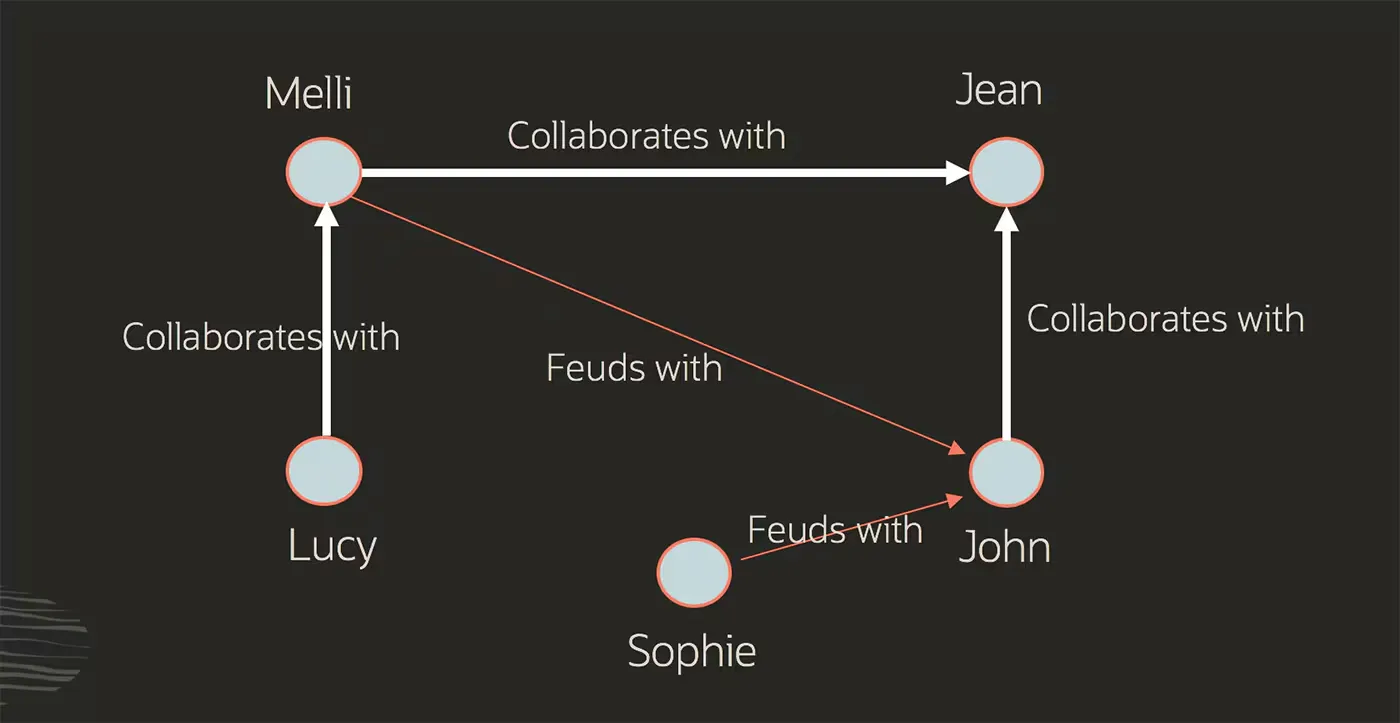

[이미지 출처] https://medium.com/@kofsitho/ep-2-graphdb-%EC%82%AC%EC%9A%A9%ED%95%98%EA%B8%B0-feat-neo4j-1504bf3bdf57

> 💡 **일상 비유로 이해하기**
>
> - **노드(Node)** = 사람, 장소, 사물 같은 "개체" (예: 엔비디아, 삼성전자, 김기자)
> - **관계(Relationship)** = 개체 사이의 "연결선" (예: 엔비디아 ─[COVERS]→ AI 반도체)
> - **속성(Property)** = 개체/연결선에 붙는 "메모" (예: 엔비디아의 설립연도=1993)
>
> 관계형 DB가 "엑셀 시트"라면, 그래프 DB는 **"마인드맵"** 입니다. 서로 어떻게 이어져 있는지 그 자체가 핵심 정보가 됩니다.


### **1.2 Neo4j 그래프 데이터베이스**

- 가장 널리 사용되는 그래프 데이터베이스
- 네이티브 그래프 저장 및 처리
- 강력한 Cypher 쿼리 언어 제공: SQL과 유사한 직관적 문법
- 확장성: 수십억 노드와 관계 처리 가능
- LangChain 통합: 완벽한 AI/ML 파이프라인 지원


### **1.3 LangChain 생태계**

- **LangChain + Neo4j 통합** : LangChain-Neo4j 패키지 

    1. **Neo4jGraph**: 그래프 데이터베이스 래퍼
    2. **Neo4jVector**: 벡터 검색 지원
    3. **GraphCypherQAChain**: 자연어 → Cypher 쿼리 변환
    4. **Neo4jChatMessageHistory**: 채팅 기록 관리

- **AI 기반 그래프 활용**
    - **RAG (Retrieval Augmented Generation)**: 그래프 + 벡터 검색
    - **자연어 쿼리**: LLM이 Cypher 쿼리 자동 생성
    - **지능형 추천**: 그래프 구조 기반 추천 시스템

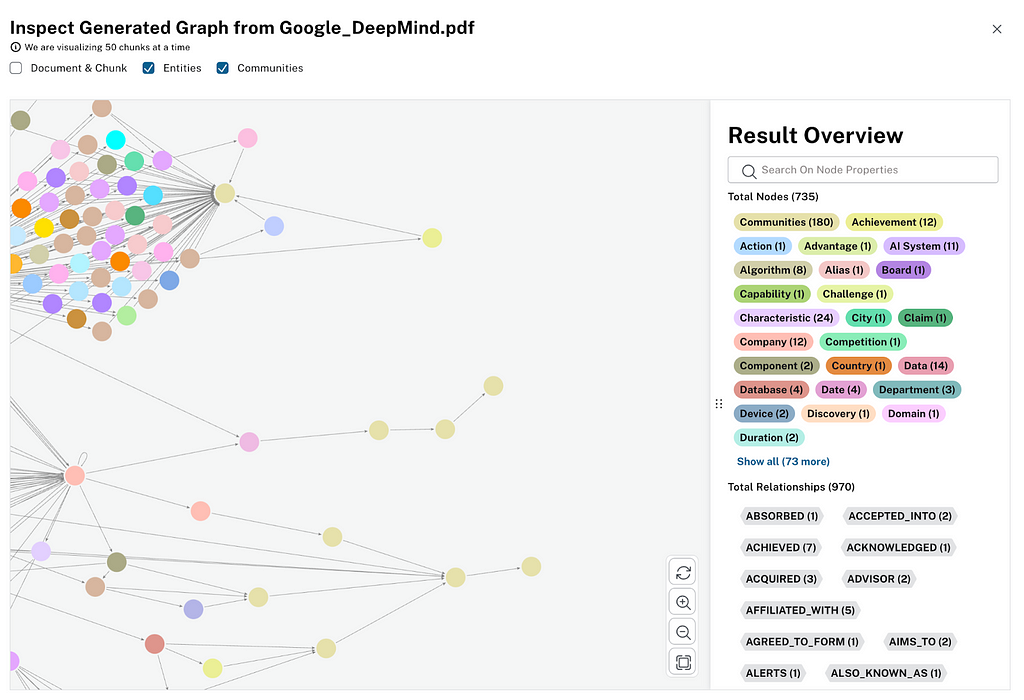

[이미지 출처] https://neo4j.com/blog/developer/knowledge-graph-builder-first/

#### 🗺️ 이 노트북에서 만들 Knowledge Graph 구조

```mermaid
graph LR
    A["Article<br/>tech-002"]
    T1["Topic<br/>AI 반도체"]
    T2["Topic<br/>기술 투자"]
    C["Company<br/>삼성전자"]
    TECH["Technology<br/>GAA"]
    P["Person<br/>젠슨 황"]
    A -->|COVERS relevance=0.95| T1
    A -->|COVERS relevance=0.9| T2
    A -->|MENTIONS| C
    A -->|DISCUSSES| TECH
    C -->|INVESTS_IN| TECH
    C -->|EMPLOYS| P
```

> 🔑 **핵심**: "노드 → 관계 → 노드" 의 연쇄가 곧 "한 편의 뉴스 기사 요약"이 됩니다. Cypher 쿼리로 이 그래프 위를 **산책하듯 질의**하는 것이 이 장의 목표입니다.


---

## **2. Neo4J AuraDB 환경 설정**

### **2.1 Neo4j AuraDB 소개**
- **정의**: Neo4j AuraDB는 완전 관리형 클라우드 서비스로 제공되는 Neo4j의 그래프 데이터베이스
- **특징**:
  - 자동 확장 및 관리
  - 항상 최신 버전 유지 (현재 Neo4j 5.x)
  - 자동 백업 및 장애 복구
  - 즉시 사용 가능한 환경 제공

### **2.2 AuraDB 인스턴스 생성**
1. **회원가입**
   - https://neo4j.com/product/auradb/ 방문
   - "Start Free" 버튼 클릭
   - 이메일로 가입 또는 Google 계정으로 가입 선택

2. **계정 생성 후 AuraDB 인스턴스 생성**
   - "New Instance" 선택
   - "Aura DB Free" 선택 (무료 티어 - 200k 노드, 400k 관계까지)

3. **데이터베이스 자격 증명 저장**
   - Username (기본값: neo4j)
   - Password (자동 생성됨, 반드시 복사해서 보관)
   - Connection URL 형태: `neo4j+s://xxxxxxx.databases.neo4j.io`

4. **연결 정보 확인**
   - 대시보드에서 인스턴스 선택
   - Connection URL 확인 (neo4j+s://*******.databases.neo4j.io)

- Neo4j Browser에서 테스트 쿼리 실행

### **2.3  Python 환경 설정**

-  **최신 라이브러리 설치**
    ```bash
    # 최신 LangChain Neo4j 통합 라이브러리 설치
    pip install -U langchain-neo4j

    # 또는 기본 Neo4j 드라이버만 사용하는 경우
    pip install neo4j

    # 환경 변수 관리용
    pip install python-dotenv
    ```

- **환경 변수 설정**
    ```bash
    # .env 파일
    NEO4J_URI=neo4j+s://xxxxxxxx.databases.neo4j.io
    NEO4J_USERNAME=xxxxxxxx
    NEO4J_PASSWORD=복사해서_저장한_Password
    NEO4J_DATABASE=xxxxxxxx
    ```

### **2.4 연결 테스트**

`(1) 최신 LangChain Neo4j 통합 사용`


In [ ]:
import os
from dotenv import load_dotenv
from langchain_neo4j import Neo4jGraph

# 환경 변수 로드
load_dotenv(override=True)

# Neo4j 연결 객체 초기화 (최신 방식)
graph = Neo4jGraph(
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"), 
    password=os.getenv("NEO4J_PASSWORD"),
    database=os.getenv("NEO4J_DATABASE")
)

# graph 스키마 최신화
graph.refresh_schema()

In [ ]:
# 연결 테스트
try:
    result = graph.query("RETURN 'Hello Neo4j!' as message")
    print("연결 성공:", result)
except Exception as e:
    print("연결 실패:", e)

`(2) 기본 Neo4j Python 드라이버 사용`

In [ ]:
from neo4j import GraphDatabase
import os
from dotenv import load_dotenv

load_dotenv()

# Python 드라이버 사용
URI = os.getenv("NEO4J_URI")
AUTH = (os.getenv("NEO4J_USERNAME"), os.getenv("NEO4J_PASSWORD"))

with GraphDatabase.driver(URI, auth=AUTH) as driver:
    # execute_query 메서드 사용
    records, summary, keys = driver.execute_query(
        "RETURN 'Hello Neo4j!' as message",
        database_name=os.getenv("NEO4J_DATABASE", "neo4j")
    )
    for record in records:
        print(record["message"])

---

## **3. 기본 데이터 모델링 및 Cypher 쿼리 사용법**

### **3.1 데이터 생성 (CREATE)**

```markdown
#### CREATE vs MERGE 비교
- **CREATE**: 항상 새로운 노드/관계 생성, 중복 허용, 빠른 실행
- **MERGE**: 존재하면 재사용, 없으면 생성, 중복 방지
```

> 🔑 **CREATE vs MERGE 빠른 의사결정**
>
```mermaid
flowchart LR
    Q([노드 만들고 싶다]) --> C1{동일 속성<br/>노드가 이미 있어도<br/>또 만들어도 되나?}
    C1 -->|예, 중복 OK| CR[CREATE<br/>항상 새로 생성]
    C1 -->|아니오, 유일해야| MG[MERGE<br/>있으면 매칭, 없으면 생성]
    CR --> W1[⚠️ 같은 쿼리 2번 = 중복 2건]
    MG --> W2[✅ 같은 쿼리 2번 = 1건 유지]
```

> ⚠️ **흔한 실수**: 데이터 적재 스크립트를 여러 번 돌렸다가 `CREATE` 때문에 노드가 N배로 불어나는 경우가 많습니다. **"Get-or-Create" 가 필요하면 무조건 `MERGE`** 라고 외우세요.


`(1) Article 노드`

In [ ]:
# 첫 번째 뉴스 기사 (CREATE 사용)
cypher_query = """
CREATE (a:Article {
    id: "tech-001",
    title: "엔비디아, AI 반도체 수요 급증으로 실적 고공행진",
    content: "엔비디아가 2024년 1분기 실적 발표에서 AI 반도체 수요 증가에 힘입어 전년 대비 200% 성장을 기록했다고 발표했다. 특히 데이터센터용 GPU 판매가 크게 증가했으며, 젠슨 황 CEO는 AI 수요가 앞으로도 지속적으로 증가할 것으로 전망했다.",
    publishDate: date("2024-03-15"),
    source: "테크경제신문",
    author: "김기자",
    category: "technology",
    wordCount: 245
})
RETURN a
"""
result = graph.query(cypher_query)
print("첫 번째 기사 생성:", result)

In [ ]:
# 두 번째 뉴스 기사 (MERGE 사용)
cypher_query = """
MERGE (a:Article {
    id: "tech-002",
    title: "삼성전자, 차세대 AI 반도체 개발 계획 발표", 
    content: "삼성전자가 차세대 AI 반도체 개발 로드맵을 공개했다. 2025년까지 1000억원을 투자해 GAA 공정 기반의 새로운 AI 가속기를 개발할 계획이며, 엔비디아와의 기술 격차를 줄이겠다는 목표다.",
    publishDate: date("2024-03-14"),
    source: "테크경제신문", 
    author: "이기자",
    category: "technology",
    wordCount: 198
})
RETURN a
"""
result = graph.query(cypher_query)
print("두 번째 기사 생성:", result)

`(2) Topic 노드`

In [ ]:
cypher_query = """
MERGE (t1:Topic {name: "AI 반도체", description: "인공지능 가속기 및 관련 기술"})
MERGE (t2:Topic {name: "기업 실적", description: "회사의 재무 성과 및 실적"})
MERGE (t3:Topic {name: "기술 투자", description: "R&D 투자 및 기술 개발"})
RETURN t1, t2, t3
"""
graph.query(cypher_query)

### 📝 연습문제

다음 기업 정보를 바탕으로 Company 노드를 생성합니다.

| 기업명 | 국가 | 설립연도 | 업종 | 시가총액 |
|--------|------|----------|------|----------|
| 엔비디아 | 미국 | 1993 | 반도체 | 1.8조달러 |
| 삼성전자 | 한국 | 1969 | 전자/반도체 | 300조원 |


In [ ]:
# 여기에 코드를 작성하세요
cypher_query = """
MERGE (c1:Company {
 name: "____",
 country: "____",
 founded: ____,
 sector: "____",
 marketCap: "____"
})
MERGE (c2:Company {
 name: "____",
 country: "____",
 founded: ____,
 sector: "____",
 marketCap: "____"
})
RETURN ____, ____
"""
graph.query(cypher_query)


<details close>
<summary>💡 정답 확인</summary>

```python
cypher_query = """
MERGE (c1:Company {
 name: "엔비디아",
 country: "미국",
 founded: 1993,
 sector: "반도체",
 marketCap: "1.8조달러"
})
MERGE (c2:Company {
 name: "삼성전자",
 country: "한국",
 founded: 1969,
 sector: "전자/반도체",
 marketCap: "300조원"
})
RETURN c1, c2
"""
graph.query(cypher_query)
```

</details>

### **3.2 데이터 조회 (READ)**

`(1) 기본 조회`

In [ ]:
# 모든 Article 노드 조회
cypher_query = """
MATCH (a:Article) 
RETURN a.id, a.title, a.publishDate, a.author
ORDER BY a.publishDate DESC
"""
graph.query(cypher_query)

### 📝 연습문제

-  모든 Topic 노드를 조회합니다.

In [ ]:
# 여기에 코드를 작성하세요.


<details close>
<summary>💡 정답 확인</summary>

```python
cypher_query = """
MATCH (t:Topic)
RETURN t.name, t.description
"""
graph.query(cypher_query)
```

</details>

`(2) 필터링`

In [ ]:
# 특정 조건 필터링 - 김기자 작성 기사 중 기술 카테고리의 기사 조회
cypher_query = """
MATCH (a:Article)
WHERE a.author = "김기자" AND a.category = "technology"
RETURN a.title, a.content
"""
graph.query(cypher_query)


### 📝 연습문제

-  name 속성이 "기술 투자"인 Topic 노드 조회

In [ ]:
# 여기에 코드를 작성하세요.


<details close>
<summary>💡 정답 확인</summary>

```python
cypher_query = """
MATCH (t:Topic)
WHERE t.name = "기술 투자"
RETURN t.name, t.description
"""
graph.query(cypher_query)
```

</details>

### **3.3 관계 생성 및 조회** 

- (노드)-[:관계명]->(노드) 구문 사용
- 관계 설계 원칙
    - 의미있는 관계 이름 사용
    - 관계의 방향성 고려
    - 관계에 속성 추가 가능
    - 다중 관계 허용

`(1) 복합 노드와 관계 생성`

In [ ]:
# 인물 노드와 관계 생성 
# 젠슨 황 CEO 노드 생성 및 엔비디아와의 관계 설정
cypher_query = """
MERGE (p:Person {
    name: "젠슨 황",
    role: "CEO", 
    nationality: "대만계 미국인",
    birthYear: 1963
})
MERGE (c:Company {name: "엔비디아"})
MERGE (p)-[r:WORKS_FOR {
    since: 1993,
    position: "CEO",
    isFounder: true
}]->(c)
RETURN p, c, r
"""
graph.query(cypher_query)

In [ ]:
# 제품 노드와 관계
# GPU 제품 노드 생성 및 엔비디아와의 관계 설정
cypher_query = """
MERGE (p:Product {
    name: "GPU",
    category: "Hardware",
    type: "Graphics Processing Unit"
})
MERGE (c:Company {name: "엔비디아"})
MERGE (p)-[r:MANUFACTURED_BY {
    since: 1999,
    primaryUse: "AI/ML Computing"
}]->(c)
RETURN p, c, r
"""
graph.query(cypher_query)

`(2) 기사-토픽-회사 관계 생성`

In [ ]:
# 첫 번째 기사의 관계들
cypher_query = """
// 노드 조회, 생성
MATCH (a:Article {id: "tech-001"})
MATCH (t1:Topic {name: "AI 반도체"})
MATCH (t2:Topic {name: "기업 실적"})
MATCH (c:Company {name: "엔비디아"})
MATCH (p:Person {name: "젠슨 황"})

// 관계 생성
MERGE (a)-[:COVERS {relevance: 0.9}]->(t1)
MERGE (a)-[:COVERS {relevance: 0.8}]->(t2)
MERGE (a)-[:MENTIONS {
    context: "실적 발표 기업",
    sentiment: "positive"
}]->(c)
MERGE (a)-[:QUOTES {
    statement: "AI 수요가 지속적으로 증가할 것",
    context: "미래 전망"
}]->(p)

RETURN a.title, "관계 생성 완료" as status
"""
graph.query(cypher_query)

### 📝 연습문제

- "tech-002" ID를 가진 기사가 다음과 같은 관계들을 가져야 합니다:

- 기사-관계 구조:

    ```markdown
    기사(tech-002)
    ├── COVERS → AI 반도체 토픽 (관련도: 0.95)
    ├── COVERS → 기술 투자 토픽 (관련도: 0.9)
    ├── MENTIONS → 삼성전자 (맥락: "기술 개발 주체", 투자금: "1000억원")
    ├── DISCUSSES → GAA 기술 (맥락: "핵심 기술", 개발단계: "계획")
    └── 삼성전자 INVESTS_IN GAA 기술 (금액: "1000억원", 기간: "2025년까지")
    ```


In [ ]:
# 기술 노드 추가
cypher_query = """
MERGE (t:Technology {
    name: "GAA",
    fullName: "Gate-All-Around",
    description: "차세대 트랜지스터 기술",
    processNode: "3nm"
})
RETURN t
"""
graph.query(cypher_query)

In [ ]:
# 여기에 코드를 작성하세요.
cypher_query = """
// 기본 노드들 매칭
MATCH (a:Article {id: "____"})
MATCH (t1:Topic {name: "____"})
MATCH (t2:Topic {name: "____"})
MATCH (c:Company {name: "____"})
MATCH (tech:Technology {name: "____"})

// 관계 생성 (빈칸을 채우세요)
MERGE (a)-[:____ {relevance: ____}]->(t1)
MERGE (a)-[:____ {relevance: ____}]->(t2)
MERGE (a)-[:____ {
 context: "____",
 investment: "____"
}]->(c)
MERGE (a)-[:____ {
 context: "____",
 developmentStage: "____"
}]->(tech)
MERGE (c)-[:____ {
 amount: "____",
 timeline: "____"
}]->(tech)

RETURN a.title, "완료" as status
"""
graph.query(cypher_query)


<details close>
<summary>💡 정답 확인</summary>

```python
cypher_query = """
// 기본 노드들 매칭
MATCH (a:Article {id: "tech-002"})
MATCH (t1:Topic {name: "AI 반도체"})
MATCH (t2:Topic {name: "기술 투자"})
MATCH (c:Company {name: "삼성전자"})
MATCH (tech:Technology {name: "GAA"})

// 관계 생성
MERGE (a)-[:COVERS {relevance: 0.95}]->(t1)
MERGE (a)-[:COVERS {relevance: 0.9}]->(t2)
MERGE (a)-[:MENTIONS {
 context: "기술 개발 주체",
 investment: "1000억원"
}]->(c)
MERGE (a)-[:DISCUSSES {
 context: "핵심 기술",
 developmentStage: "계획"
}]->(tech)
MERGE (c)-[:INVESTS_IN {
 amount: "1000억원",
 timeline: "2025년까지"
}]->(tech)

RETURN a.title, "완료" as status
"""
graph.query(cypher_query)
```

</details>

In [ ]:
# 특정 토픽을 다루는 기사 찾기 (name: "AI")

cypher_query = """
MATCH (a:Article)-[:COVERS]->(t:Topic)
WHERE t.name CONTAINS "AI"
RETURN a.title;
"""
graph.query(cypher_query)

In [ ]:
# 특정 토픽과 관련된 모든 기사와 회사 찾기
cypher_query = """
MATCH path = (a:Article)-[:COVERS]->(t:Topic {name: "AI 반도체"})<-[:COVERS]-(a2:Article)-[:MENTIONS]->(c:Company)
RETURN DISTINCT a.title, a2.title, c.name, length(path) as pathLength
ORDER BY pathLength
"""
graph.query(cypher_query)

### 📝 연습문제

- 특정 기술을 다루는 기사 찾기 (name: "GAA", relationship: MENTIONS)

In [ ]:
# 여기에 코드를 작성하세요.


<details close>
<summary>💡 정답 확인</summary>

```python
cypher_query = """
MATCH (a:Article)-[:DISCUSSES]->(tech:Technology)
WHERE tech.name = "GAA"
RETURN a.title, a.content
"""
graph.query(cypher_query)
```

</details>

### **3.4 데이터 수정 (UPDATE)**
- SET 구문을 통한 속성 수정
- 관계 수정 방법
- REMOVE를 통한 속성 제거

In [ ]:
# 노드 속성 수정 - SET 사용
cypher_query = """
MATCH (c:Company {name: '엔비디아'})
SET c.revenue = '18.1억 달러',
    c.headquarters = '캘리포니아'
RETURN c.name, c.revenue, c.headquarters
"""
graph.query(cypher_query)

In [ ]:
# 관계 속성 수정
cypher_query = """
MATCH (a:Article {id: 'tech-002'})-[r:MENTIONS]->(c:Company {name: '삼성전자'})
SET r.context = '기술 개발 주체',
    r.investment = '1000억원'
RETURN a.title, r.context, r.investment
"""
graph.query(cypher_query)

### **3.5  데이터 삭제 (DELETE)**
- DELETE vs DETACH DELETE
- 노드 삭제 시 주의사항
- 관계 삭제

> ⚠️ **DELETE vs DETACH DELETE — 가장 잦은 함정**
>
> - `DELETE n`: 노드 `n` 을 삭제. **단, `n` 에 붙은 관계가 하나라도 있으면 에러**.
> - `DETACH DELETE n`: 노드 + 연결된 모든 관계를 **함께** 삭제.
>
> 👉 "이 노드를 확실히 지우고 싶다" 면 `DETACH DELETE` 를 쓰세요. 반대로, 관계가 남아있는지 먼저 확인하고 싶다면 `DELETE` 로 에러를 유도해보는 것도 안전 장치가 됩니다.


In [ ]:
# 테스트용 노드 및 관계 생성
cypher_query = """
// 테스트용 기사 노드 생성
CREATE (a:Article {
    id: 'test-001',
    title: '테스트 기사',
    content: '이 기사는 삭제 테스트를 위한 것입니다.'
})

// 테스트용 토픽 생성
CREATE (t:Topic {name: '테스트 토픽'})

// 테스트용 회사 생성
CREATE (c:Company {
    name: '테스트 기업',
    country: '한국',
    sector: '테스트'
})

// 관계 생성
CREATE (a)-[:COVERS]->(t)
CREATE (a)-[:MENTIONS {
    context: "테스트 컨텍스트",
    test_property: true
}]->(c)

RETURN '테스트 데이터가 생성되었습니다.' as result
"""
graph.query(cypher_query)

In [ ]:
# 특정 관계만 삭제
cypher_query = """
// MENTIONS 관계만 삭제
MATCH (a:Article {id: 'test-001'})-[r:MENTIONS]->(c:Company {name: '테스트 기업'})
DELETE r
RETURN '테스트 기사의 MENTIONS 관계가 삭제되었습니다.' as result
"""
graph.query(cypher_query)

In [ ]:
# 관계 포함 삭제 (DETACH DELETE)
cypher_query = """
// Article 노드와 연결된 모든 관계를 포함해 삭제
MATCH (a:Article {id: 'test-001'})
DETACH DELETE a
RETURN '테스트 기사와 관련 관계가 모두 삭제되었습니다.' as result
"""
graph.query(cypher_query)

---
## **4. LangChain을 활용한 Text-to-Cypher**

### **4.1 LangChain 통합 설정**

- LangChain으로 Neo4J 지식 그래프 조회
- https://python.langchain.com/docs/integrations/graphs/neo4j_cypher/

`(1) 스키마 최적화`

In [ ]:
# 그래프 스키마 새로고침 및 확인
graph.refresh_schema()
print("현재 그래프 스키마:")
print(graph.schema)

In [ ]:
# 스키마 개선을 위한 인덱스 생성 
# 인덱스 - Neo4j에서 성능을 향상시키기 위해 인덱스를 생성합니다.
# 인덱스는 특정 속성에 대한 빠른 조회를 가능하게 합니다.
# 예를 들어, Article의 id, Company의 name, Topic의 name에 인덱스를 생성하여 검색 성능을 향상시킬 수 있습니다.

# 각 인덱스를 개별적으로 생성
index_queries = [
    "CREATE INDEX article_id_index IF NOT EXISTS FOR (a:Article) ON (a.id)",
    "CREATE INDEX company_name_index IF NOT EXISTS FOR (c:Company) ON (c.name)",
    "CREATE INDEX topic_name_index IF NOT EXISTS FOR (t:Topic) ON (t.name)"
]

for query in index_queries:
    try:
        graph.query(query)
        print(f"인덱스 생성 완료: {query}")
    except Exception as e:
        # 이미 존재하는 인덱스인 경우 무시
        if "already exists" in str(e).lower() or "equivalent" in str(e).lower():
            print(f"인덱스 이미 존재: {query}")
        else:
            print(f"인덱스 생성 실패: {e}")

In [ ]:
# 생성된 인덱스 확인
result = graph.query("SHOW INDEXES")

for record in result:
    print(f"이름: {record.get('name', 'N/A')}")
    print(f"상태: {record.get('state', 'N/A')}")
    print(f"타입: {record.get('type', 'N/A')}")
    print("-" * 30)

`(2) LLM 모델 설정`

In [ ]:
from langchain_neo4j import GraphCypherQAChain
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
import os

# LLM 모델 초기화
gemini = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0,
    # google_api_key=os.getenv("GOOGLE_API_KEY")
)

gpt = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
    # api_key=os.getenv("OPENAI_API_KEY")
)

# 최신 GraphCypherQAChain 설정
gemini_chain = GraphCypherQAChain.from_llm(
    llm=gemini,
    graph=graph,
    allow_dangerous_requests=True,  # ⚠️ 주의: 학습 환경에서만 사용. 프로덕션에서는 쿼리 검증 필요
    verbose=True,
    return_intermediate_steps=True,  # 중간 단계 반환
    top_k=10  # 결과 수 제한
)

gpt_chain = GraphCypherQAChain.from_llm(
    llm=gpt,
    graph=graph,
    allow_dangerous_requests=True,  # ⚠️ 주의: 학습 환경에서만 사용. 프로덕션에서는 쿼리 검증 필요
    verbose=True,
    return_intermediate_steps=True,
    top_k=10
)

### **4.2 Text to Cypher 쿼리**

> 💡 **Text-to-Cypher 가 뭐 하는 녀석인가요?**
>
> 사용자가 "삼성전자가 투자한 기술은?" 이라고 **자연어**로 물으면, LLM이 이를 
> `MATCH (c:Company {name:"삼성전자"})-[:INVESTS_IN]->(t) RETURN t.name` 같은 **Cypher**로 
> 번역해주는 "그래프 통역사" 입니다.
>
> 🔑 **품질을 좌우하는 3요소**: 
> 1. **스키마 주입** — LLM이 그래프의 노드/관계 이름을 정확히 알아야 합니다. 
> 2. **예시(few-shot)** — "이런 질문은 이런 Cypher로" 예시를 2~3개 제공하면 정확도 급증. 
> 3. **검증** — LLM이 생성한 Cypher 를 실행 전에 `EXPLAIN` 으로 문법 체크하면 안전합니다.


`(1) 기본 질의응답`

In [ ]:
# 단순 카운트 질의
response = gemini_chain.invoke({
    "query": "엔비디아를 언급한 기사는 모두 몇 개인가요?"
})
print("Gemini 응답:", response)

In [ ]:
response = gpt_chain.invoke({
    "query": "엔비디아를 언급한 기사는 모두 몇 개인가요?"
})
print("GPT 응답:", response)

`(2) 복합 분석 질의`

In [ ]:
# 내용 분석 질의
queries = [
    "엔비디아와 관련된 기사의 주요 내용과 키워드를 요약해주세요.",
    "삼성전자가 투자하고 있는 기술은 무엇이고, 투자 규모는 얼마인가요?",
    "AI 반도체 토픽을 다루는 기사들에 언급된 회사들과 그들의 관계를 설명해주세요.",
    "기술 투자 관련 기사에서 언급된 투자 금액과 기간을 알려주세요."
]

for query in queries:
    print(f"\n질문: {query}")
    print("=" * 50)
    
    try:
        gemini_response = gemini_chain.invoke({"query": query})
        print(f"Gemini: {gemini_response['result']}")
    except Exception as e:
        print(f"Gemini 오류: {e}")

    try:
        gpt_response = gpt_chain.invoke({"query": query})
        print(f"GPT: {gpt_response['result']}")
    except Exception as e:
        print(f"GPT 오류: {e}")
    print("-" * 50)

### 📝 연습문제

- 여기에 여러분만의 질문을 작성하고 실행해보세요. (Text to Cypher 쿼리)

In [ ]:
# 여기에 코드를 작성하세요.

advanced_queries = [
    "질문 1",
    "질문 2",
    "질문 3",
    "질문 4",
]


<details close>
<summary>💡 정답 확인</summary>

```python
advanced_queries = [
    "AI 반도체 토픽을 다루는 기사들의 작성자와 출처를 알려주세요.",
    "삼성전자가 투자하고 있는 기술의 세부 정보는 무엇인가요?",
    "엔비디아 CEO가 언급된 기사의 제목과 인용 내용을 보여주세요.",
    "2024년 3월 15일 이후에 발행된 기사들의 주요 토픽을 요약해주세요.",
]
```

</details>

In [ ]:
# 실습 코드를 여기에 작성하세요.


<details close>
<summary>💡 정답 확인</summary>

```python
for query in advanced_queries:
    print(f"\n질문: {query}")
    print("=" * 50)
    
    try:
        gemini_response = gemini_chain.invoke({"query": query})
        print(f"Gemini: {gemini_response['result']}")
    except Exception as e:
        print(f"Gemini 오류: {e}")

    try:
        gpt_response = gpt_chain.invoke({"query": query})
        print(f"GPT: {gpt_response['result']}")
    except Exception as e:
        print(f"GPT 오류: {e}")
    print("-" * 50)
```

</details>

---

## **5. 성능 최적화 및 고급 기능**

### **5.1 인덱스 및 제약조건**

`(1) 복합 인덱스 (Composite Index)`

- **개념**:
    - 복합 인덱스는 **여러 속성을 함께 인덱싱**하는 방식입니다. 
    - 단일 속성이 아닌 **여러 속성의 조합**으로 검색할 때 성능을 크게 향상시킵니다.

- **활용**:

    1. **다중 조건 쿼리 최적화**
        ```cypher
        // 복합 인덱스가 있으면 이런 쿼리가 빨라집니다
        MATCH (a:Article)
        WHERE a.publishDate >= date('2023-01-01') AND a.author = 'John Smith'
        RETURN a.title
        ```

    2. **범위 검색 + 정확 일치 조합**
        ```cypher
        // 국가와 산업 분야로 회사 검색
        MATCH (c:Company)
        WHERE c.country = 'USA' AND c.sector = 'Technology'
        RETURN c.name
        ```

    3. **정렬 성능 향상**
        ```cypher
        // 복합 인덱스 순서에 따른 정렬 최적화
        MATCH (a:Article)
        WHERE a.author = 'Jane Doe'
        RETURN a.title
        ORDER BY a.publishDate DESC
        ```

In [ ]:
# 복합 인덱스 생성

cypher_queries = [
    "CREATE INDEX article_date_author IF NOT EXISTS FOR (a:Article) ON (a.publishDate, a.author);",
    "CREATE INDEX company_country_sector IF NOT EXISTS FOR (c:Company) ON (c.country, c.sector);"
]

for query in cypher_queries:
    graph.query(query)

In [ ]:
# 복합 인덱스가 생성되었는지 확인
result = graph.query("SHOW INDEXES")
for record in result:
    print(f"이름: {record.get('name', 'N/A')}")
    print(f"상태: {record.get('state', 'N/A')}")
    print(f"타입: {record.get('type', 'N/A')}")
    print("-" * 30)

`(2) 유일성 제약조건 (Uniqueness Constraints)`

- **개념**:
  - 특정 레이블의 노드에서 **지정된 속성의 값이 고유해야 함**을 보장하는 데이터베이스 제약조건입니다.

- **주요 특징**:
  - **데이터 무결성 보장**: 중복 데이터 방지
  - **자동 인덱스 생성**: 유일성 제약조건 생성 시 자동으로 인덱스도 생성됨
  - **성능 향상**: 고유 값 검색 시 빠른 성능 제공

In [ ]:
# 유일성 제약조건 (기존 인덱스와 겹치지 않는 제약조건)
cypher_query = """
CREATE CONSTRAINT technology_name_unique IF NOT EXISTS FOR (t:Technology) REQUIRE t.name IS UNIQUE;
"""
graph.query(cypher_query)

In [ ]:
# 복합 인덱스가 생성되었는지 확인
result = graph.query("SHOW INDEXES")
for record in result:
    print(f"이름: {record.get('name', 'N/A')}")
    print(f"상태: {record.get('state', 'N/A')}")
    print(f"타입: {record.get('type', 'N/A')}")
    print("-" * 30)

### **5.2 배치 데이터 처리**

In [ ]:
# 대량 데이터 효율적 처리 (UNWIND 사용)
def create_articles_batch(articles_data):
    cypher_query = """
    UNWIND $articles as article       // UNWIND를 사용하여 대량 데이터 처리
    MERGE (a:Article {id: article.id})
    SET a.title = article.title,
        a.content = article.content,
        a.publishDate = date(article.publishDate),
        a.author = article.author,
        a.source = article.source
    RETURN count(a) as created_count
    """
    
    result = graph.query(
        cypher_query, 
        params={"articles": articles_data} # 파라미터로 데이터 전달
        )
    return result

In [ ]:
# 사용 예제 추가 
sample_articles = [
    {
        "id": "tech-003",
        "title": "AI 칩 시장 전망",
        "content": "AI 칩 시장이 급성장하고 있다. 2024년에는 500억 달러 규모에 이를 것으로 예상된다.",
        "publishDate": "2024-03-16",
        "author": "박기자",
        "source": "AI타임즈"
    },
    {
        "id": "tech-004",
        "title": "AI 반도체 기술의 미래",
        "content": "AI 반도체 기술이 발전하면서 새로운 혁신이 기대된다.",
        "publishDate": "2024-03-17",
        "author": "이기자",
        "source": "테크월드"
    },
    {
        "id": "tech-005",
        "title": "AI 반도체의 시장 점유율 변화",
        "content": "AI 반도체의 시장 점유율이 2023년 대비 20% 증가했다.",
        "publishDate": "2024-03-18",
        "author": "김기자",
        "source": "테크뉴스"
    },
    {        
        "id": "tech-006",
        "title": "AI 반도체의 기술 혁신",
        "content": "AI 반도체 기술이 혁신을 이루고 있다. 새로운 제조 공정이 도입되었다.",
        "publishDate": "2024-03-19",
        "author": "박기자",
        "source": "AI타임즈"
    },
    {
        "id": "tech-007",
        "title": "AI 반도체의 글로벌 시장 동향",
        "content": "글로벌 AI 반도체 시장이 빠르게 성장하고 있다. 주요 기업들이 시장에 진입하고 있다.",
        "publishDate": "2024-03-20",
        "author": "이기자",
        "source": "테크월드"
    },
    {
        "id": "tech-008",
        "title": "AI 반도체의 기술 발전",
        "content": "AI 반도체 기술이 발전하면서 새로운 응용 분야가 열리고 있다.",
        "publishDate": "2024-03-21",
        "author": "김기자",
        "source": "테크뉴스"
    },
    {
        "id": "tech-009",
        "title": "AI 반도체의 시장 전망",
        "content": "AI 반도체 시장이 2025년까지 1000억 달러 규모에 이를 것으로 예상된다.",
        "publishDate": "2024-03-22",
        "author": "박기자",
        "source": "AI타임즈"
    },
    {
        "id": "tech-010",
        "title": "AI 반도체의 기술 혁신",
        "content": "AI 반도체 기술이 혁신을 이루고 있다. 새로운 제조 공정이 도입되었다.",
        "publishDate": "2024-03-23",
        "author": "이기자",
        "source": "테크월드"
    },
]

result = create_articles_batch(sample_articles)
print("배치 처리 결과:", result)

### **5.3 그래프 분석 [심화]**

`(1) 네트워크 분석`

In [ ]:
# (n)--() 구문: Cypher에서 노드 n과 연결된 모든 노드를 찾는 구문
cypher_query = """
// 중심성 분석 - 가장 많이 연결된 노드
MATCH (n)
RETURN 
    labels(n)[0] as nodeType,
    n.name as nodeName,
    COUNT { (n)--() } as connections
ORDER BY connections DESC
LIMIT 10
"""
result = graph.query(cypher_query)
print("연결 중심성:", len(result))

for record in result:
    print(f"노드 타입: {record['nodeType']}, 노드 이름: {record['nodeName']}, 연결 수: {record['connections']}")

In [ ]:
# (n)--() 구문: Cypher에서 노드 n과 연결된 모든 노드를 찾는 구문
# (n)-->() 구문: Cypher에서 노드 n에서 나가는 모든 연결을 찾는 구문
# (n)<--() 구문: Cypher에서 노드 n로 들어오는 모든 연결을 찾는 구문

connection_types_query = """
// 연결 중심성 - 노드와 연결된 관계 유형별로 분석
MATCH (n)
WHERE COUNT { (n)--() } > 0
RETURN 
    labels(n)[0] as nodeType,
    COUNT { (n)--() } as totalConnections,
    COUNT { (n)-->() } as outgoingConnections,
    COUNT { (n)<--() } as incomingConnections
ORDER BY totalConnections DESC
LIMIT 5
"""
result = graph.query(connection_types_query)
print("연결 중심성 (관계 유형별):", len(result))

for record in result:
    print(f"노드 타입: {record['nodeType']}, 총 연결 수: {record['totalConnections']}, 나가는 연결 수: {record['outgoingConnections']}, 들어오는 연결 수: {record['incomingConnections']}")

In [ ]:
# startNode(r)와 endNode(r) 사용
# startNode(r): 관계 r의 시작 노드
# endNode(r): 관계 r의 끝 노드
# type(r): 관계 r의 유형
# COUNT(r): 관계 r의 개수

relationship_analysis_query = """
// 관계 유형별 연결 분석
MATCH (n)-[r]->()
RETURN 
    type(r) as relationshipType,
    COUNT(r) as relationshipCount,
    COUNT(DISTINCT startNode(r)) as uniqueSourceNodes,
    COUNT(DISTINCT endNode(r)) as uniqueTargetNodes
ORDER BY relationshipCount DESC
"""

result = graph.query(relationship_analysis_query)
for record in result:
    print(f"  {record['relationshipType']}: {record['relationshipCount']}개, "
            f"소스 {record['uniqueSourceNodes']}개, "
            f"대상 {record['uniqueTargetNodes']}개")
print()

`(2) 패스 분석 및 연결성 분석`

In [ ]:
# 최단 경로 분석 (회사-기술 간 최단 경로)
shortest_paths_query = """
MATCH (start:Company), (end:Technology)
WHERE start.name IS NOT NULL AND end.name IS NOT NULL
// 최단 경로를 찾기 위한 쿼리 (shortestPath 사용해서 1~3단계 경로)
WITH start, end, shortestPath((start)-[*1..3]-(end)) as path
WHERE path IS NOT NULL
RETURN 
    start.name as startCompany,
    end.name as endTechnology,
    length(path) as pathLength,
    [node in nodes(path) | labels(node)[0]] as nodeTypes
ORDER BY pathLength ASC
LIMIT 10
"""

result = graph.query(shortest_paths_query)
for record in result:
    print(f"  {record['startCompany']} → {record['endTechnology']}: "
            f"{record['pathLength']}단계 ({' → '.join(record['nodeTypes'])})")
print()

In [ ]:
# 연결 컴포넌트 분석 
component_analysis_query = """
MATCH (n)
WHERE COUNT { (n)--() } > 0
WITH n
MATCH path = (n)-[*1..2]-()
WITH collect(DISTINCT nodes(path)) as component
UNWIND component as nodes
UNWIND nodes as node
WITH DISTINCT node
RETURN 
    labels(node)[0] as nodeType,
    count(node) as connectedNodes
ORDER BY connectedNodes DESC
"""

# 노드와 연결된 타입 분포
result = graph.query(component_analysis_query)
for record in result:
    print(f"  {record['nodeType']}: {record['connectedNodes']}개 노드")
print()